# 21 — Cluster Randomization Null

```text
Reviewer concern addressed: R1-c (implied) -- clustering is a hard statistical problem;
    per-cluster enrichment differences could be "purely statistical" rather than biological.
    Implements frozen-plan Phase 3 notebook 21, the last of four Go/No-Go-checkpoint inputs
    (10, 11, 20, 21).
Input files: data/yeast/gi_pcc_sampled.tsv, data/yeast/go_bp_name_to_orfs.json
    (hashes cross-checked against 00_environment_check_manifest.json)
HiMaLAYAS version: verified git tag v0.0.15, activated via
    revision_utils.activate_pinned_source() -- the same pattern 01/10/11/20 established.
Random seed: DEFAULT_RANDOM_SEED=0 (revision_utils.seeds); randomization seeds derived as
    [DEFAULT_RANDOM_SEED + i for i in range(N_REPLICATIONS)].
Primary parameters: reference clustering reproduced verbatim from fig_1.ipynb
    (linkage_method="ward", linkage_metric="euclidean", linkage_threshold=16,
    optimal_ordering=True, min_cluster_size=30, min_overlap=2, qval<=0.05), providing the
    fixed 7-cluster size distribution [148, 92, 263, 358, 78, 52, 62] (sums to all 1053
    genes). Real GO annotations held fixed throughout. N_REPLICATIONS=1000.
Outputs written:
    revision/outputs/manifests/21_cluster_randomization_null_manifest.json
    revision/outputs/tables/21_cluster_randomization_null/*.csv
    revision/outputs/figures/21_cluster_randomization_null/*.png
Interpretation: see the GO / CONDITIONAL_GO / CONCERN decision in the final section.
```

## Design

This is the mirror image of notebook 20. There, clustering was held fixed and annotations
were shuffled; here, **annotations are held fixed** (the real GO BP mapping) and **cluster
membership is shuffled**, subject to reproducing the reference clustering's exact 7-way size
distribution -- i.e. every replicate asks: "if genes were partitioned into 7 groups of sizes
148/92/263/358/78/52/62 *arbitrarily*, rather than by GI-profile similarity, would enrichment
this strong still turn up?"

`himalayas.core.enrichment.run_cluster_hypergeom(matrix, clusters, annotations, ...)` only
ever accesses `clusters.unique_clusters`, `clusters.cluster_to_labels[cid]`, and
`clusters.cluster_sizes[cid]` (confirmed by reading `himalayas/core/enrichment.py`) -- it does
not require a real `himalayas.core.clustering.Clusters` instance (which can only be
constructed from an actual linkage matrix via `fcluster`, not from an arbitrary externally
specified partition). Each replicate therefore builds a lightweight duck-typed stand-in
(`types.SimpleNamespace` exposing exactly those three attributes) from one random permutation
of the 1053-gene universe sliced into the reference's exact size chunks, and passes it
directly to the same public enrichment function the library itself uses. No package code is
touched.

## 1. Locate repo root and import shared revision utilities

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    markers = ("himalayas_src", "data", ".git", "revision")
    for candidate in (start, *start.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(f"Could not locate himalayas-publication repo root above {start}")


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
SRC_DIR = REPO_ROOT / "revision" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Kernel CWD:  {Path.cwd()}")
print(f"Repo root:   {REPO_ROOT}")

Kernel CWD:  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/notebooks
Repo root:   /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication


In [2]:
import json
import warnings
from datetime import datetime, timezone
from types import SimpleNamespace

import numpy as np
import pandas as pd

import revision_utils as ru
from revision_utils import DEFAULT_RANDOM_SEED, revision_layout

layout = revision_layout(REPO_ROOT)
for key in ("manifests_dir", "figures_dir", "tables_dir", "scratch_dir"):
    layout[key].mkdir(parents=True, exist_ok=True)

NB_ID = "21_cluster_randomization_null"
NB_FIGURES_DIR = layout["figures_dir"] / NB_ID
NB_TABLES_DIR = layout["tables_dir"] / NB_ID
NB_SCRATCH_DIR = layout["scratch_dir"] / NB_ID
for d in (NB_FIGURES_DIR, NB_TABLES_DIR, NB_SCRATCH_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Figures ->", NB_FIGURES_DIR)
print("Tables  ->", NB_TABLES_DIR)
print("Scratch ->", NB_SCRATCH_DIR)

Figures -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/21_cluster_randomization_null
Tables  -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/21_cluster_randomization_null
Scratch -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/21_cluster_randomization_null


## 2. Recall notebooks 00/01/10/11/20 findings

In [3]:
nb00_manifest = ru.read_manifest(layout["manifests_dir"] / "00_environment_check_manifest.json")
nb01_manifest = ru.read_manifest(
    layout["manifests_dir"] / "01_reproduce_submitted_figures_manifest.json"
)
nb10_manifest = ru.read_manifest(
    layout["manifests_dir"] / "10_noise_robustness_gi_pcc_manifest.json"
)
nb11_manifest = ru.read_manifest(
    layout["manifests_dir"] / "11_depth_threshold_sensitivity_manifest.json"
)
nb20_manifest = ru.read_manifest(
    layout["manifests_dir"] / "20_annotation_permutation_null_manifest.json"
)

print("00_environment_check flags:")
for f in nb00_manifest["flags"]:
    print(f"  - {f}")
print()
for nb_name, m in [("10", nb10_manifest), ("11", nb11_manifest), ("20", nb20_manifest)]:
    print(f"{nb_name}: status={m['status']} decision={m['decision']}")
print(f"\n20's next_action: {nb20_manifest['next_action']}")

himalayas_diag_before = ru.himalayas_diagnostics(layout["repo_root"])
print()
print(
    f"Active kernel HiMaLAYAS (before activation below): {himalayas_diag_before['imported_version']} "
    f"(editable={himalayas_diag_before['is_editable_install']})"
)

00_environment_check flags:
  - ACTIVE HiMaLAYAS VERSION MISMATCH: kernel imports '0.0.16a0' but README pins '0.0.15'.
  - EDITABLE HiMaLAYAS SOURCE IS DIRTY: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas has 5 uncommitted path(s): ['M src/himalayas/__init__.py', '?? PREVIEW_NOTES.md', '?? _archive/', '?? preview-release-notes.sh', '?? test.py'].
  - EDITABLE HiMaLAYAS SOURCE IS AHEAD OF ITS LAST TAG: git describe = 'v0.0.15-4-g0c51115'.
  - VENDORED COPY VERSION DIFFERS FROM IMPORTED VERSION: himalayas_src/ declares '0.0.15', kernel imports '0.0.16a0'.
  - PUBLICATION REPO HAS UNCOMMITTED/UNTRACKED PATHS: 6 path(s) -- expected during active revision work (e.g. this new revision/ tree itself); noted for provenance only.

10: status=COMPLETE decision=GO
11: status=COMPLETE decision=GO
20: status=COMPLETE decision=GO

20's next_action: Proceed to 21_cluster_randomization_null.ipynb. Observed cluster-term enrichment (331 significant pairs,


Active kernel HiMaLAYAS (before activation below): 0.0.16a0 (editable=True)


## 3. Activate the verified pinned v0.0.15 source

In [4]:
PINNED_TAG = "v0.0.15"

try:
    activation = ru.activate_pinned_source(
        layout["repo_root"], NB_SCRATCH_DIR / "himalayas_pinned_v0_0_15", tag=PINNED_TAG
    )
    activation_error = None
except RuntimeError as exc:
    activation = None
    activation_error = str(exc)

if activation is not None:
    print(json.dumps(activation, indent=2))
else:
    print(f"ACTIVATION FAILED: {activation_error}")

import himalayas
from himalayas import Analysis, Annotations, Matrix
from himalayas.core.enrichment import run_cluster_hypergeom

print()
print(f"himalayas module now bound to: {himalayas.__file__}")
print(f"himalayas.__version__:         {himalayas.__version__}")

if activation is not None:
    assert (
        himalayas.__version__ == "0.0.15"
    ), f"Expected pinned v0.0.15 after activation, got {himalayas.__version__!r}"
    assert activation["matches_requested_tag"], "activate_pinned_source reported a version mismatch"
    print("\nConfirmed: this notebook's HiMaLAYAS analyses run under verified tag v0.0.15.")

{
  "requested_tag": "v0.0.15",
  "sibling_repo": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas",
  "pinned_src_dir": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/21_cluster_randomization_null/himalayas_pinned_v0_0_15/src",
  "activated_version": "0.0.15",
  "activated_file": "/Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/21_cluster_randomization_null/himalayas_pinned_v0_0_15/src/himalayas/__init__.py",
  "matches_requested_tag": true
}

himalayas module now bound to: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/21_cluster_randomization_null/himalayas_pinned_v0_0_15/src/himalayas/__init__.py
himalayas.__version__:         0.0.15

Confirmed: this notebook's HiMaLAYAS analyses run under verified tag v0

## 4. Load inputs and cross-check hashes against notebook 00

In [5]:
GI_PCC_PATH = layout["repo_root"] / "data" / "yeast" / "gi_pcc_sampled.tsv"
GO_BP_PATH = layout["repo_root"] / "data" / "yeast" / "go_bp_name_to_orfs.json"

current_hashes = {
    "data/yeast/gi_pcc_sampled.tsv": ru.sha256_file(GI_PCC_PATH),
    "data/yeast/go_bp_name_to_orfs.json": ru.sha256_file(GO_BP_PATH),
}
recorded_hashes = {r["path"]: r["sha256"] for r in nb00_manifest["input_files"]}

input_hash_flags = []
for rel_path, current_hash in current_hashes.items():
    recorded_hash = recorded_hashes.get(rel_path)
    matches = current_hash == recorded_hash
    print(f"{rel_path}: matches 00_environment_check record = {matches}")
    if not matches:
        input_hash_flags.append(
            f"INPUT HASH MISMATCH: {rel_path} changed since 00_environment_check ran "
            f"(recorded {recorded_hash}, now {current_hash})."
        )

DF_GI_PCC = pd.read_csv(GI_PCC_PATH, sep="\t", index_col=0)
with open(GO_BP_PATH, "r", encoding="utf-8") as fh:
    go_bp = json.load(fh)

print()
print(f"Matrix shape: {DF_GI_PCC.shape}")
print(f"GO BP terms loaded: {len(go_bp):,}")

data/yeast/gi_pcc_sampled.tsv: matches 00_environment_check record = True
data/yeast/go_bp_name_to_orfs.json: matches 00_environment_check record = True

Matrix shape: (1053, 1053)
GO BP terms loaded: 1,095


## 5. Reference analysis (fixed annotations, observed enrichment)

Reproduces fig_1.ipynb's exact configuration and cross-checks against notebooks 01/10/11/20's recorded reproduction (709 / 331 / 7). The resulting cluster **sizes** (not membership) are what every randomized replicate below must reproduce exactly.

In [6]:
REFERENCE_THRESHOLD = 16
REFERENCE_MIN_SIZE = 30
LINKAGE_METHOD = "ward"
LINKAGE_METRIC = "euclidean"
OPTIMAL_ORDERING = True
MIN_OVERLAP = 2
QVAL_CUTOFF = 0.05

with warnings.catch_warnings():
    warnings.simplefilter(
        "ignore", RuntimeWarning
    )  # expected: GO terms outside the matrix universe
    reference_matrix = Matrix(DF_GI_PCC)
    reference_annotations = Annotations(go_bp, reference_matrix)
    reference_analysis = (
        Analysis(reference_matrix, reference_annotations)
        .cluster(
            linkage_method=LINKAGE_METHOD,
            linkage_metric=LINKAGE_METRIC,
            linkage_threshold=REFERENCE_THRESHOLD,
            optimal_ordering=OPTIMAL_ORDERING,
            min_cluster_size=REFERENCE_MIN_SIZE,
        )
        .enrich(min_overlap=MIN_OVERLAP)
        .finalize(col_cluster=False)
    )

reference_results = reference_analysis.results
reference_results_sig = reference_results.filter(f"qval <= {QVAL_CUTOFF}")
reference_cluster_labels = reference_results_sig.cluster_labels(rank_by="p", label_mode="top_term")
reference_top_term_by_cluster = dict(
    zip(reference_cluster_labels["cluster"], reference_cluster_labels["term"])
)

OBSERVED_N_SIG = len(reference_results_sig.df)
OBSERVED_MIN_PVAL = float(reference_results.df["pval"].min())

print(
    f"Reference: {len(reference_results.df)} enriched rows, {OBSERVED_N_SIG} significant "
    f"(q<={QVAL_CUTOFF}), {len(reference_cluster_labels)} labeled clusters"
)
print(f"Observed minimum p-value: {OBSERVED_MIN_PVAL:.3e}")

expected = nb20_manifest["reference_reproduction_check"]
reproduction_matches = (
    len(reference_results.df) == expected["results_rows"]
    and OBSERVED_N_SIG == expected["results_sig_rows"]
    and len(reference_cluster_labels) == expected["n_clusters"]
)
print(
    f"\nMatches notebooks 01/10/11/20's recorded fig_1.ipynb baseline (709/331/7): {reproduction_matches}"
)
assert (
    reproduction_matches
), "Reference analysis does not match the prior baseline -- stop and investigate"

reference_cluster_labels

Reference: 709 enriched rows, 331 significant (q<=0.05), 7 labeled clusters
Observed minimum p-value: 1.799e-42

Matches notebooks 01/10/11/20's recorded fig_1.ipynb baseline (709/331/7): True


,cluster,label,pval,qval,score,n,term,fe
0,1,GPI anchor biosynthetic process,3.222730e-12,8.788137e-11,3.222730e-12,148,GPI anchor biosynthetic process,5.568155
1,2,vesicle-mediated transport,1.237408e-26,4.386613e-24,1.237408e-26,92,vesicle-mediated transport,7.868886
2,3,"mRNA splicing, via spliceosome",2.829998e-16,1.433192e-14,2.829998e-16,263,"mRNA splicing, via spliceosome",3.745492
3,4,cytoplasmic translation,8.925220e-15,3.954988e-13,8.925220e-15,358,cytoplasmic translation,2.852209
4,5,mitochondrial respiratory chain complex IV ass...,1.794876e-19,1.590709e-17,1.794876e-19,78,mitochondrial respiratory chain complex IV ass...,12.750000
5,6,DNA replication,1.798541e-42,1.275166e-39,1.798541e-42,52,DNA replication,16.011628
6,7,cell division,2.138848e-20,2.707850e-18,2.138848e-20,62,cell division,8.177419


## 6. Reference cluster sizes and per-cluster significant-pair counts

In [7]:
REFERENCE_CLUSTER_SIZES = {
    int(cid): int(n) for cid, n in reference_analysis.clusters.cluster_sizes.items()
}
REFERENCE_CLUSTER_IDS = sorted(REFERENCE_CLUSTER_SIZES)
SIZE_LIST = [REFERENCE_CLUSTER_SIZES[cid] for cid in REFERENCE_CLUSTER_IDS]

real_sig_per_cluster = reference_results_sig.df.groupby("cluster").size().to_dict()
real_sig_per_cluster = {cid: int(real_sig_per_cluster.get(cid, 0)) for cid in REFERENCE_CLUSTER_IDS}

assert sum(SIZE_LIST) == len(reference_matrix.labels), (
    "reference cluster sizes do not sum to the full gene universe -- clustering must be a "
    "complete partition for the size-preserving null to be well-defined"
)

print(
    f"Reference cluster sizes: {REFERENCE_CLUSTER_SIZES}  (sum={sum(SIZE_LIST)}, "
    f"gene universe={len(reference_matrix.labels)})"
)
print(
    f"Real significant pairs per cluster: {real_sig_per_cluster}  (total={sum(real_sig_per_cluster.values())})"
)

dominant_cluster_id = max(real_sig_per_cluster, key=real_sig_per_cluster.get)
single_cluster_dominance_frac = real_sig_per_cluster[dominant_cluster_id] / OBSERVED_N_SIG
print(
    f"\nMost sig-heavy real cluster: {dominant_cluster_id} "
    f"({reference_top_term_by_cluster[dominant_cluster_id]}, "
    f"{real_sig_per_cluster[dominant_cluster_id]}/{OBSERVED_N_SIG} = "
    f"{single_cluster_dominance_frac:.1%} of all significant pairs)"
)

Reference cluster sizes: {1: 148, 6: 52, 2: 92, 4: 358, 5: 78, 7: 62, 3: 263}  (sum=1053, gene universe=1053)
Real significant pairs per cluster: {1: 59, 2: 47, 3: 61, 4: 30, 5: 26, 6: 57, 7: 51}  (total=331)

Most sig-heavy real cluster: 3 (mRNA splicing, via spliceosome, 61/331 = 18.4% of all significant pairs)


## 7. Randomization design and seed policy

In [8]:
N_REPLICATIONS = 1000
RANDOMIZATION_SEEDS = [DEFAULT_RANDOM_SEED + i for i in range(N_REPLICATIONS)]
GENE_UNIVERSE = reference_matrix.labels  # fixed order, length 1053

print(f"N_REPLICATIONS: {N_REPLICATIONS}")
print(
    f"Seed rule: seed = DEFAULT_RANDOM_SEED + i for i in range(N_REPLICATIONS), "
    f"DEFAULT_RANDOM_SEED={DEFAULT_RANDOM_SEED}"
)
print(f"First/last seeds: {RANDOMIZATION_SEEDS[0]}, {RANDOMIZATION_SEEDS[-1]}")


def make_random_clusters(rng):
    """One random partition of the fixed gene universe into 7 groups reproducing the
    reference's exact size distribution (cid -> size mapping preserved so cid 6 is always
    the 52-gene slot, etc., giving a stable per-cluster-size correspondence across replicates).
    Returns a duck-typed stand-in exposing exactly what run_cluster_hypergeom needs."""
    perm = rng.permutation(len(GENE_UNIVERSE))
    shuffled_genes = GENE_UNIVERSE[perm]
    cluster_to_labels = {}
    start = 0
    for cid, size in zip(REFERENCE_CLUSTER_IDS, SIZE_LIST):
        cluster_to_labels[cid] = set(shuffled_genes[start : start + size])
        start += size
    cluster_sizes = {cid: len(genes) for cid, genes in cluster_to_labels.items()}
    return SimpleNamespace(
        unique_clusters=list(cluster_to_labels.keys()),
        cluster_to_labels=cluster_to_labels,
        cluster_sizes=cluster_sizes,
    )


# Sanity check: one sample partition reproduces the exact reference size multiset.
_sample = make_random_clusters(np.random.default_rng(RANDOMIZATION_SEEDS[0]))
assert _sample.cluster_sizes == REFERENCE_CLUSTER_SIZES, "random partition size mismatch"
assert sum(len(v) for v in _sample.cluster_to_labels.values()) == len(GENE_UNIVERSE)
print("Sanity check passed: random partitions reproduce the exact reference size distribution.")

N_REPLICATIONS: 1000
Seed rule: seed = DEFAULT_RANDOM_SEED + i for i in range(N_REPLICATIONS), DEFAULT_RANDOM_SEED=0
First/last seeds: 0, 999
Sanity check passed: random partitions reproduce the exact reference size distribution.


## 8. Run the cluster-randomization null

Real GO annotations (`reference_annotations`) are reused unchanged every replicate -- only cluster membership is randomized, via the same low-level `run_cluster_hypergeom` call notebook 20 used (bypassing `Analysis.cluster()`, which cannot accept an externally specified partition).

In [9]:
null_global_rows = []
null_cluster_rows = []

t_start = datetime.now(timezone.utc)
for i, seed in enumerate(RANDOMIZATION_SEEDS):
    rng = np.random.default_rng(seed)
    random_clusters = make_random_clusters(rng)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        random_results = run_cluster_hypergeom(
            reference_matrix, random_clusters, reference_annotations, min_overlap=MIN_OVERLAP
        ).with_qvalues(method="global")
    random_results_sig = random_results.filter(f"qval <= {QVAL_CUTOFF}")
    random_term_sets = ru.cluster_term_sets(random_results_sig.df)
    random_sig_per_cluster = (
        random_results_sig.df.groupby("cluster").size().to_dict()
        if len(random_results_sig.df)
        else {}
    )

    n_sig = len(random_results_sig.df)
    min_pval = float(random_results.df["pval"].min()) if len(random_results.df) else 1.0
    max_sig_per_cluster = max(random_sig_per_cluster.values()) if random_sig_per_cluster else 0
    null_global_rows.append(
        {
            "seed": seed,
            "n_sig": n_sig,
            "min_pval": min_pval,
            "max_sig_per_cluster": max_sig_per_cluster,
        }
    )

    for ref_cid in REFERENCE_CLUSTER_IDS:
        ref_term = reference_top_term_by_cluster.get(ref_cid)
        null_cluster_rows.append(
            {
                "seed": seed,
                "ref_cluster_id": ref_cid,
                "ref_top_term": ref_term,
                "ref_cluster_size": REFERENCE_CLUSTER_SIZES[ref_cid],
                "random_cluster_n_sig_terms": int(random_sig_per_cluster.get(ref_cid, 0)),
                "ref_top_term_significant_in_random_cluster": bool(
                    ref_term is not None and ref_term in random_term_sets.get(ref_cid, set())
                ),
            }
        )

    if (i + 1) % 200 == 0 or i == 0:
        elapsed = (datetime.now(timezone.utc) - t_start).total_seconds()
        print(f"  {i + 1}/{N_REPLICATIONS} replicates done ({elapsed:.1f}s elapsed)")

null_distribution = pd.DataFrame(null_global_rows)
per_cluster_size_null_check_raw = pd.DataFrame(null_cluster_rows)
print(f"\nCompleted {len(null_distribution)} randomization replicates.")

n_sig_value_counts = null_distribution["n_sig"].value_counts().sort_index()
n_sig_breakdown = ", ".join(
    f"{int(count)}/{len(null_distribution)} replicates produced {int(val)}"
    for val, count in n_sig_value_counts.items()
)
print(f"Null n_sig breakdown: {n_sig_breakdown} (observed={OBSERVED_N_SIG})")
print(
    f"Null min_pval: min={null_distribution['min_pval'].min():.3e} "
    f"mean={null_distribution['min_pval'].mean():.3e} max={null_distribution['min_pval'].max():.3e}"
)
print(
    f"Null max_sig_per_cluster: mean={null_distribution['max_sig_per_cluster'].mean():.3f} "
    f"max={null_distribution['max_sig_per_cluster'].max()}  "
    f"(real max across reference clusters: {max(real_sig_per_cluster.values())})"
)

  1/1000 replicates done (0.1s elapsed)


  200/1000 replicates done (19.3s elapsed)


  400/1000 replicates done (38.9s elapsed)


  600/1000 replicates done (58.6s elapsed)


  800/1000 replicates done (78.5s elapsed)


  1000/1000 replicates done (98.6s elapsed)

Completed 1000 randomization replicates.
Null n_sig breakdown: 959/1000 replicates produced 0, 34/1000 replicates produced 1, 7/1000 replicates produced 2 (observed=331)
Null min_pval: min=7.695e-08 mean=1.133e-03 max=6.954e-03
Null max_sig_per_cluster: mean=0.046 max=2  (real max across reference clusters: 61)


## 9. Observed-vs-null summary and empirical p-values

In [10]:
def empirical_pvalue(null_values, observed, direction):
    null_values = np.asarray(null_values)
    if direction == "greater_or_equal":
        n_at_least_as_extreme = int((null_values >= observed).sum())
    elif direction == "less_or_equal":
        n_at_least_as_extreme = int((null_values <= observed).sum())
    else:
        raise ValueError(direction)
    return (1 + n_at_least_as_extreme) / (1 + len(null_values))


empirical_p_n_sig = empirical_pvalue(null_distribution["n_sig"], OBSERVED_N_SIG, "greater_or_equal")
empirical_p_min_pval = empirical_pvalue(
    null_distribution["min_pval"], OBSERVED_MIN_PVAL, "less_or_equal"
)
REAL_MAX_SIG_PER_CLUSTER = max(real_sig_per_cluster.values())
empirical_p_max_sig_per_cluster = empirical_pvalue(
    null_distribution["max_sig_per_cluster"], REAL_MAX_SIG_PER_CLUSTER, "greater_or_equal"
)

observed_vs_null_summary = pd.DataFrame(
    [
        {
            "metric": "n_significant_cluster_term_pairs (q<=0.05)",
            "observed_value": OBSERVED_N_SIG,
            "null_mean": null_distribution["n_sig"].mean(),
            "null_median": null_distribution["n_sig"].median(),
            "null_std": null_distribution["n_sig"].std(),
            "null_min": null_distribution["n_sig"].min(),
            "null_max": null_distribution["n_sig"].max(),
            "empirical_pvalue": empirical_p_n_sig,
        },
        {
            "metric": "min_pval (strongest single cluster-term signal)",
            "observed_value": OBSERVED_MIN_PVAL,
            "null_mean": null_distribution["min_pval"].mean(),
            "null_median": null_distribution["min_pval"].median(),
            "null_std": null_distribution["min_pval"].std(),
            "null_min": null_distribution["min_pval"].min(),
            "null_max": null_distribution["min_pval"].max(),
            "empirical_pvalue": empirical_p_min_pval,
        },
        {
            "metric": "max_significant_pairs_in_any_single_cluster (optional)",
            "observed_value": REAL_MAX_SIG_PER_CLUSTER,
            "null_mean": null_distribution["max_sig_per_cluster"].mean(),
            "null_median": null_distribution["max_sig_per_cluster"].median(),
            "null_std": null_distribution["max_sig_per_cluster"].std(),
            "null_min": null_distribution["max_sig_per_cluster"].min(),
            "null_max": null_distribution["max_sig_per_cluster"].max(),
            "empirical_pvalue": empirical_p_max_sig_per_cluster,
        },
    ]
)
observed_vs_null_summary

,metric,observed_value,null_mean,null_median,null_std,null_min,null_max,empirical_pvalue
0,n_significant_cluster_term_pairs (q<=0.05),3.310000e+02,0.048000,0.000000,0.244450,0.000000e+00,2.000000,0.000999
1,min_pval (strongest single cluster-term signal),1.798541e-42,0.001133,0.000824,0.001003,7.694732e-08,0.006954,0.000999
2,max_significant_pairs_in_any_single_cluster (o...,6.100000e+01,0.046000,0.000000,0.232245,0.000000e+00,2.000000,0.000999


In [11]:
per_cluster_size_null_check = (
    per_cluster_size_null_check_raw.groupby(["ref_cluster_id", "ref_top_term", "ref_cluster_size"])
    .agg(
        n_replicates=("seed", "count"),
        real_n_sig_terms=("ref_cluster_id", lambda s: real_sig_per_cluster[s.iloc[0]]),
        mean_random_n_sig_terms=("random_cluster_n_sig_terms", "mean"),
        max_random_n_sig_terms=("random_cluster_n_sig_terms", "max"),
        rate_top_term_significant_by_chance=("ref_top_term_significant_in_random_cluster", "mean"),
    )
    .reset_index()
    .sort_values("ref_cluster_id")
)
per_cluster_size_null_check

,ref_cluster_id,ref_top_term,ref_cluster_size,n_replicates,real_n_sig_terms,mean_random_n_sig_terms,max_random_n_sig_terms,rate_top_term_significant_by_chance
0,1,GPI anchor biosynthetic process,148,1000,59,0.007,2,0.0
1,2,vesicle-mediated transport,92,1000,47,0.013,2,0.0
2,3,"mRNA splicing, via spliceosome",263,1000,61,0.004,1,0.0
3,4,cytoplasmic translation,358,1000,30,0.004,1,0.0
4,5,mitochondrial respiratory chain complex IV ass...,78,1000,26,0.007,2,0.0
5,6,DNA replication,52,1000,57,0.007,2,0.0
6,7,cell division,62,1000,51,0.006,1,0.0


## 10. Write tables

In [12]:
TABLES = {
    "null_distribution.csv": null_distribution,
    "observed_vs_null_summary.csv": observed_vs_null_summary,
    "per_cluster_size_null_check.csv": per_cluster_size_null_check,
}
table_paths = {}
for name, df in TABLES.items():
    out_path = NB_TABLES_DIR / name
    df.to_csv(out_path, index=False)
    table_paths[name] = str(out_path.relative_to(layout["repo_root"]))
    print(f"wrote {out_path}  ({len(df)} rows)")

wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/21_cluster_randomization_null/null_distribution.csv  (1000 rows)
wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/21_cluster_randomization_null/observed_vs_null_summary.csv  (3 rows)
wrote /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/21_cluster_randomization_null/per_cluster_size_null_check.csv  (7 rows)


## 11. Observed signal vs random-cluster null

Same honest off-scale handling as notebook 20: the null n_sig distribution is shown on its own linear range (observed=331 fits within it), while the null min-p-value distribution spans only a few orders of magnitude and is shown on its own natural range with the observed value called out by annotation rather than compressed onto a shared axis.

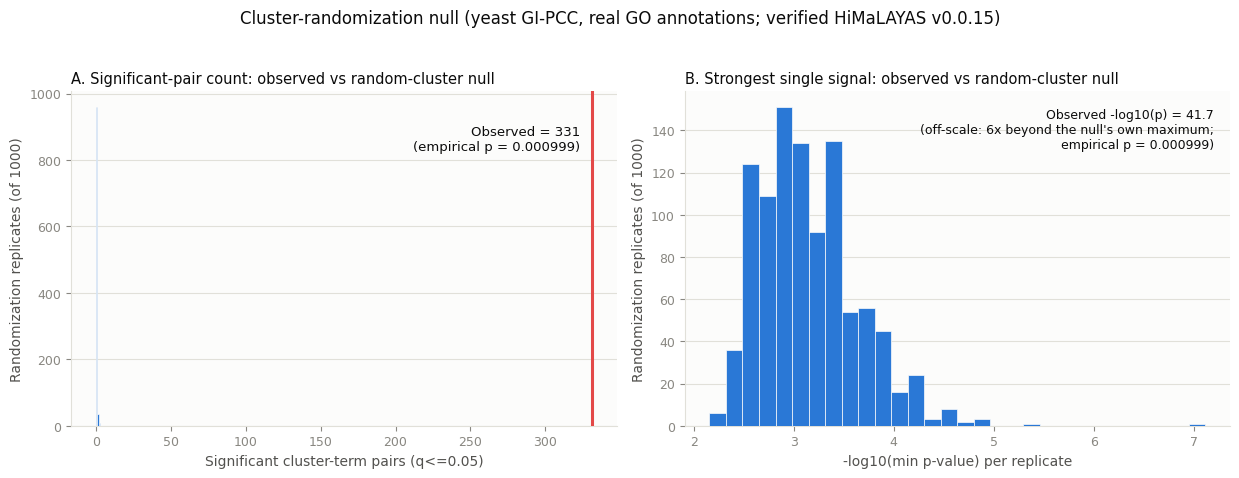

Saved /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/21_cluster_randomization_null/null_vs_observed.png


In [13]:
import matplotlib.pyplot as plt

CATEGORICAL_PALETTE = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
    "#e34948",
]
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"


def style_axis(ax):
    ax.set_facecolor("#fcfcfb")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(GRIDLINE)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]
style_axis(ax)
ax.hist(
    null_distribution["n_sig"],
    bins=range(0, max(int(null_distribution["n_sig"].max()) + 2, 10)),
    color=CATEGORICAL_PALETTE[0],
    edgecolor="#fcfcfb",
    linewidth=0.5,
    zorder=3,
)
ax.axvline(OBSERVED_N_SIG, color=CATEGORICAL_PALETTE[7], linewidth=2.2, zorder=4)
ax.annotate(
    f"Observed = {OBSERVED_N_SIG}\n(empirical p = {empirical_p_n_sig:.3g})",
    xy=(OBSERVED_N_SIG, ax.get_ylim()[1] * 0.9),
    xytext=(-8, 0),
    textcoords="offset points",
    ha="right",
    va="top",
    fontsize=9.5,
    color=INK_PRIMARY,
)
ax.set_xlabel("Significant cluster-term pairs (q<=0.05)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(f"Randomization replicates (of {N_REPLICATIONS})", color=INK_SECONDARY, fontsize=10)
ax.set_title(
    "A. Significant-pair count: observed vs random-cluster null",
    color=INK_PRIMARY,
    fontsize=10.5,
    loc="left",
)

ax = axes[1]
style_axis(ax)
neg_log10_null = -np.log10(null_distribution["min_pval"].clip(lower=1e-300))
ax.hist(
    neg_log10_null,
    bins=30,
    color=CATEGORICAL_PALETTE[0],
    edgecolor="#fcfcfb",
    linewidth=0.5,
    zorder=3,
)
null_max_neg_log10 = float(neg_log10_null.max())
observed_neg_log10 = -np.log10(max(OBSERVED_MIN_PVAL, 1e-300))
ax.annotate(
    f"Observed -log10(p) = {observed_neg_log10:.1f}\n"
    f"(off-scale: {observed_neg_log10 / null_max_neg_log10:.0f}x beyond the null's own maximum;\n"
    f"empirical p = {empirical_p_min_pval:.3g})",
    xy=(0.97, 0.95),
    xycoords="axes fraction",
    ha="right",
    va="top",
    fontsize=9,
    color=INK_PRIMARY,
)
ax.set_xlabel("-log10(min p-value) per replicate", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(f"Randomization replicates (of {N_REPLICATIONS})", color=INK_SECONDARY, fontsize=10)
ax.set_title(
    "B. Strongest single signal: observed vs random-cluster null",
    color=INK_PRIMARY,
    fontsize=10.5,
    loc="left",
)

fig.suptitle(
    "Cluster-randomization null (yeast GI-PCC, real GO annotations; verified HiMaLAYAS v0.0.15)",
    color=INK_PRIMARY,
    fontsize=12,
    y=1.03,
)
fig.tight_layout()
null_vs_observed_path = NB_FIGURES_DIR / "null_vs_observed.png"
fig.savefig(null_vs_observed_path, dpi=200, bbox_inches="tight", facecolor="#fcfcfb")
plt.show()
print(f"Saved {null_vs_observed_path}")

## 12. GO / CONDITIONAL_GO / CONCERN decision

Decision rule (this notebook's brief), driven by the *worse* (more conservative) of the two primary empirical p-values, with an explicit check for single-cluster dominance:

- **CONCERN**: the worse empirical p-value exceeds 0.05 -- random same-size clusters produce comparable significant-pair counts or top signal to the observed data.
- **CONDITIONAL_GO**: the worse empirical p-value is small but not at the resolution floor (modest margin), OR more than half of all observed significant pairs come from a single reference cluster (the aggregate result is not broadly distributed across clusters).
- **GO**: the worse empirical p-value sits at the resolution floor AND no single cluster accounts for the majority of the signal.

In [14]:
floor_pvalue = 1 / (N_REPLICATIONS + 1)
worst_empirical_p = max(empirical_p_n_sig, empirical_p_min_pval)
SINGLE_CLUSTER_DOMINANCE_THRESHOLD = 0.5

print(f"empirical_p (n_sig):              {empirical_p_n_sig:.3g}")
print(f"empirical_p (min_pval):           {empirical_p_min_pval:.3g}")
print(f"empirical_p (max_sig_per_cluster, optional metric): {empirical_p_max_sig_per_cluster:.3g}")
print(f"resolution floor:                 {floor_pvalue:.3g}  (1 / (N_REPLICATIONS + 1))")
print(f"worst (governing) empirical p-value: {worst_empirical_p:.3g}")
print(
    f"single-cluster dominance fraction:   {single_cluster_dominance_frac:.1%} "
    f"(cluster {dominant_cluster_id}: {reference_top_term_by_cluster[dominant_cluster_id]})"
)

if worst_empirical_p > 0.05:
    decision = "CONCERN"
elif worst_empirical_p > floor_pvalue:
    decision = "CONDITIONAL_GO"
elif single_cluster_dominance_frac >= SINGLE_CLUSTER_DOMINANCE_THRESHOLD:
    decision = "CONDITIONAL_GO"
else:
    decision = "GO"

print(f"\nDECISION: {decision}")

empirical_p (n_sig):              0.000999
empirical_p (min_pval):           0.000999
empirical_p (max_sig_per_cluster, optional metric): 0.000999
resolution floor:                 0.000999  (1 / (N_REPLICATIONS + 1))
worst (governing) empirical p-value: 0.000999
single-cluster dominance fraction:   18.4% (cluster 3: mRNA splicing, via spliceosome)

DECISION: GO


## 13. Assemble and write manifest

In [15]:
flags = list(input_hash_flags)
if activation is None:
    flags.append(f"HIMALAYAS ACTIVATION FAILED: {activation_error}")

CLAIM_BOUNDARY = (
    "This notebook tests whether arbitrary clusters with the same size distribution as the "
    "reference clustering reproduce the observed enrichment signal, using the real GO "
    "annotations throughout. It does not test every possible clustering algorithm or every "
    "possible biological dataset -- it is one specific, size-matched randomization null on "
    "one specific matrix."
)

if decision == "GO":
    next_action = (
        "All four Go/No-Go-checkpoint notebooks (10, 11, 20, 21) are GO. Per the frozen plan "
        "Section 4, proceed to the full manuscript rewrite: reframe novelty, expand Methods, "
        f"and move to 30_related_tool_comparison_table.ipynb / 40_biological_utility_case_"
        f"study.ipynb. Observed cluster-term enrichment ({OBSERVED_N_SIG} significant pairs, "
        f"min p={OBSERVED_MIN_PVAL:.2e}) is beaten by none of {N_REPLICATIONS} random "
        "same-size-cluster nulls, and is not concentrated in a single dominant cluster "
        f"({single_cluster_dominance_frac:.1%} from the largest contributor)."
    )
elif decision == "CONDITIONAL_GO":
    reason = (
        f"the margin is modest (worst empirical p={worst_empirical_p:.3g})"
        if worst_empirical_p > floor_pvalue
        else f"{single_cluster_dominance_frac:.1%} of the observed signal comes from a single "
        f"cluster (cluster {dominant_cluster_id})"
    )
    next_action = (
        "Proceed to the manuscript rewrite with narrowed claims (frozen plan Section 4): "
        f"the random-cluster null is favorable but {reason}. Frame HiMaLAYAS as an "
        "annotation/prioritization aid rather than claiming uniformly strong enrichment "
        "across every cluster, and state this operating caveat in the response to reviewers."
    )
else:
    next_action = (
        "PAUSE manuscript polish. Random clusters with the same size distribution as the "
        f"reference produce comparable significant-pair counts or top signal (worst "
        f"empirical p={worst_empirical_p:.3g}). Reconsider claims, figures, or venue before "
        "investing further time (frozen plan Section 4, No-Go response)."
    )

manifest = {
    "notebook": "21_cluster_randomization_null.ipynb",
    "status": "COMPLETE" if activation is not None else "BLOCKED",
    "decision": decision,
    "next_action": next_action,
    "generated_at_utc": ru.utc_timestamp(),
    "repo_root": str(layout["repo_root"]),
    "himalayas_source": activation if activation is not None else {"error": activation_error},
    "himalayas_diagnostics_at_start": himalayas_diag_before,
    "input_files": {
        "gi_pcc_matrix": {
            "path": "data/yeast/gi_pcc_sampled.tsv",
            "sha256": current_hashes["data/yeast/gi_pcc_sampled.tsv"],
            "matches_nb00_record": current_hashes["data/yeast/gi_pcc_sampled.tsv"]
            == recorded_hashes.get("data/yeast/gi_pcc_sampled.tsv"),
        },
        "go_bp_annotations": {
            "path": "data/yeast/go_bp_name_to_orfs.json",
            "sha256": current_hashes["data/yeast/go_bp_name_to_orfs.json"],
            "matches_nb00_record": current_hashes["data/yeast/go_bp_name_to_orfs.json"]
            == recorded_hashes.get("data/yeast/go_bp_name_to_orfs.json"),
        },
    },
    "reference_config": {
        "linkage_method": LINKAGE_METHOD,
        "linkage_metric": LINKAGE_METRIC,
        "linkage_threshold": REFERENCE_THRESHOLD,
        "optimal_ordering": OPTIMAL_ORDERING,
        "min_cluster_size": REFERENCE_MIN_SIZE,
        "min_overlap": MIN_OVERLAP,
        "qval_cutoff": QVAL_CUTOFF,
    },
    "reference_reproduction_check": {
        "matches_nb01_nb10_nb11_nb20_baseline": bool(reproduction_matches),
        "results_rows": len(reference_results.df),
        "results_sig_rows": OBSERVED_N_SIG,
        "n_clusters": len(reference_cluster_labels),
        "observed_min_pval": OBSERVED_MIN_PVAL,
        "reference_cluster_sizes": REFERENCE_CLUSTER_SIZES,
        "real_sig_per_cluster": real_sig_per_cluster,
    },
    "randomization_design": {
        "method": (
            "Real GO BP annotations held fixed. Each replicate draws one uniform random "
            "permutation of the fixed 1053-gene matrix universe and slices it into 7 "
            "contiguous chunks reproducing the reference clustering's exact per-cluster-id "
            "size distribution (SimpleNamespace duck-typed stand-in exposing unique_clusters/"
            "cluster_to_labels/cluster_sizes, passed directly to "
            "himalayas.core.enrichment.run_cluster_hypergeom -- no real Clusters object or "
            "package modification involved)."
        ),
        "n_replications": N_REPLICATIONS,
        "default_random_seed": DEFAULT_RANDOM_SEED,
        "seed_rule": "seed = DEFAULT_RANDOM_SEED + i for i in range(N_REPLICATIONS)",
        "first_seed": RANDOMIZATION_SEEDS[0],
        "last_seed": RANDOMIZATION_SEEDS[-1],
    },
    "observed_vs_null": {
        "n_sig": {
            "observed": OBSERVED_N_SIG,
            "null_mean": float(null_distribution["n_sig"].mean()),
            "null_max": int(null_distribution["n_sig"].max()),
            "empirical_pvalue": empirical_p_n_sig,
        },
        "min_pval": {
            "observed": OBSERVED_MIN_PVAL,
            "null_mean": float(null_distribution["min_pval"].mean()),
            "null_min": float(null_distribution["min_pval"].min()),
            "empirical_pvalue": empirical_p_min_pval,
        },
        "max_sig_per_cluster_optional": {
            "observed": REAL_MAX_SIG_PER_CLUSTER,
            "null_mean": float(null_distribution["max_sig_per_cluster"].mean()),
            "null_max": int(null_distribution["max_sig_per_cluster"].max()),
            "empirical_pvalue": empirical_p_max_sig_per_cluster,
        },
        "resolution_floor": floor_pvalue,
        "worst_empirical_pvalue": worst_empirical_p,
        "single_cluster_dominance_frac": single_cluster_dominance_frac,
        "dominant_cluster_id": int(dominant_cluster_id),
    },
    "flags": flags,
    "outputs": {
        "tables": table_paths,
        "figures": {
            "null_vs_observed.png": str(null_vs_observed_path.relative_to(layout["repo_root"]))
        },
    },
    "claim_boundary": CLAIM_BOUNDARY,
    "interpretation": (
        f"Decision={decision}. Claim: arbitrary same-size gene partitions do not reproduce "
        f"the observed enrichment signal. Observed {OBSERVED_N_SIG} significant cluster-term "
        f"pairs (q<=0.05) vs a null over {N_REPLICATIONS} randomizations of gene membership "
        f"across clusters reproducing the reference's exact size distribution "
        f"{REFERENCE_CLUSTER_SIZES}: {n_sig_breakdown} significant pair(s), with no replicate "
        f"exceeding {int(null_distribution['n_sig'].max())} (empirical p={empirical_p_n_sig:.3g}). "
        f"Observed minimum p-value {OBSERVED_MIN_PVAL:.2e} vs null range "
        f"[{null_distribution['min_pval'].min():.2e}, {null_distribution['min_pval'].max():.2e}] "
        f"(empirical p={empirical_p_min_pval:.3g}). The largest single real cluster "
        f"({dominant_cluster_id}, {reference_top_term_by_cluster[dominant_cluster_id]}) "
        f"accounts for {single_cluster_dominance_frac:.1%} of observed significant pairs -- "
        f"{'below' if single_cluster_dominance_frac < SINGLE_CLUSTER_DOMINANCE_THRESHOLD else 'at or above'} "
        f"the {SINGLE_CLUSTER_DOMINANCE_THRESHOLD:.0%} dominance threshold, so the result is "
        "not driven by one outlier cluster. per_cluster_size_null_check.csv gives the "
        "per-annotation breakdown; see the claim_boundary field for this notebook's scope."
    ),
}

manifest_path = layout["manifests_dir"] / f"{NB_ID}_manifest.json"
ru.write_manifest(manifest, manifest_path)
print(f"Manifest written to: {manifest_path}")

reloaded = json.loads(manifest_path.read_text())
assert reloaded == json.loads(json.dumps(manifest, default=str)), "manifest round-trip mismatch"
print("Manifest JSON round-trip verified.")

Manifest written to: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/manifests/21_cluster_randomization_null_manifest.json
Manifest JSON round-trip verified.


## 14. Readiness summary

In [16]:
print("=" * 72)
print(f"DECISION -- {NB_ID}")
print("=" * 72)
print(f"status:      {manifest['status']}")
print(f"decision:    {manifest['decision']}")
print(f"next_action: {manifest['next_action']}")
print()
print(
    f"HiMaLAYAS source: {activation['activated_version'] if activation else 'N/A'} "
    f"(verified tag {PINNED_TAG}, not the active dev install)"
)
print(f"Reference reproduction matches notebooks 01/10/11/20: {reproduction_matches}")
print()
print("Observed vs null summary:")
display(observed_vs_null_summary)
print()
print("Per-cluster-size null check:")
display(
    per_cluster_size_null_check[
        [
            "ref_cluster_id",
            "ref_top_term",
            "ref_cluster_size",
            "real_n_sig_terms",
            "mean_random_n_sig_terms",
            "rate_top_term_significant_by_chance",
        ]
    ]
)
print()
print("Claim boundary:")
print(f"  {manifest['claim_boundary']}")
print()
print(f"Manifest:  {manifest_path}")
print(f"Tables:    {NB_TABLES_DIR}")
print(f"Figures:   {NB_FIGURES_DIR}")

DECISION -- 21_cluster_randomization_null
status:      COMPLETE
decision:    GO
next_action: All four Go/No-Go-checkpoint notebooks (10, 11, 20, 21) are GO. Per the frozen plan Section 4, proceed to the full manuscript rewrite: reframe novelty, expand Methods, and move to 30_related_tool_comparison_table.ipynb / 40_biological_utility_case_study.ipynb. Observed cluster-term enrichment (331 significant pairs, min p=1.80e-42) is beaten by none of 1000 random same-size-cluster nulls, and is not concentrated in a single dominant cluster (18.4% from the largest contributor).

HiMaLAYAS source: 0.0.15 (verified tag v0.0.15, not the active dev install)
Reference reproduction matches notebooks 01/10/11/20: True

Observed vs null summary:


,metric,observed_value,null_mean,null_median,null_std,null_min,null_max,empirical_pvalue
0,n_significant_cluster_term_pairs (q<=0.05),3.310000e+02,0.048000,0.000000,0.244450,0.000000e+00,2.000000,0.000999
1,min_pval (strongest single cluster-term signal),1.798541e-42,0.001133,0.000824,0.001003,7.694732e-08,0.006954,0.000999
2,max_significant_pairs_in_any_single_cluster (o...,6.100000e+01,0.046000,0.000000,0.232245,0.000000e+00,2.000000,0.000999



Per-cluster-size null check:


,ref_cluster_id,ref_top_term,ref_cluster_size,real_n_sig_terms,mean_random_n_sig_terms,rate_top_term_significant_by_chance
0,1,GPI anchor biosynthetic process,148,59,0.007,0.0
1,2,vesicle-mediated transport,92,47,0.013,0.0
2,3,"mRNA splicing, via spliceosome",263,61,0.004,0.0
3,4,cytoplasmic translation,358,30,0.004,0.0
4,5,mitochondrial respiratory chain complex IV ass...,78,26,0.007,0.0
5,6,DNA replication,52,57,0.007,0.0
6,7,cell division,62,51,0.006,0.0



Claim boundary:
  This notebook tests whether arbitrary clusters with the same size distribution as the reference clustering reproduce the observed enrichment signal, using the real GO annotations throughout. It does not test every possible clustering algorithm or every possible biological dataset -- it is one specific, size-matched randomization null on one specific matrix.

Manifest:  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/manifests/21_cluster_randomization_null_manifest.json
Tables:    /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/21_cluster_randomization_null
Figures:   /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/21_cluster_randomization_null
